# Helmet Detection — End to End ML Project


## Phase 1 — Setup & Imports
Importing all required libraries for data processing, visualization and model building.

In [59]:
import os
import xml.etree.ElementTree as ET
from PIL import Image
import shutil
import matplotlib.pyplot as plt
import random

## Phase 2 — Data Collection
**Dataset:** [Kaggle - andrewmvd/helmet-detection](https://www.kaggle.com/datasets/andrewmvd/helmet-detection)  


In [60]:
folders = [
    'dataset/train/helmet',
    'dataset/train/no_helmet',
    'dataset/val/helmet',
    'dataset/val/no_helmet'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Folder structure created!")

✅ Folder structure created!


## Phase 3 — Preprocessing

### Step 1 — Parse XML & Extract Crops


In [ ]:
IMAGES_DIR = 'images'
ANNOTATIONS_DIR = 'annotations'
OUTPUT_DIR = 'dataset'
SPLIT_RATIO = 0.8  


all_crops = []  

for xml_file in os.listdir(ANNOTATIONS_DIR):
    if not xml_file.endswith('.xml'):
        continue

    xml_path = os.path.join(ANNOTATIONS_DIR, xml_file)
    tree = ET.parse(xml_path)
    root = tree.getroot()

    
    img_filename = root.find('filename').text
    img_path = os.path.join(IMAGES_DIR, img_filename)

    if not os.path.exists(img_path):
        continue

    
    for obj in root.findall('object'):
        label_raw = obj.find('name').text.strip().lower()

        if 'without' in label_raw:
            label = 'no_helmet'
        else:
            label = 'helmet'

        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))

        all_crops.append((img_path, (xmin, ymin, xmax, ymax), label))

print(f"✅ Total crops found: {len(all_crops)}")

✅ Total crops found: 1451


### Step 2 — Save Crops into Train/Val folders


In [ ]:

random.seed(42)
random.shuffle(all_crops)


split_idx = int(len(all_crops) * SPLIT_RATIO)
train_crops = all_crops[:split_idx]
val_crops   = all_crops[split_idx:]

def save_crops(crops, split):
    saved = 0
    for idx, (img_path, bbox, label) in enumerate(crops):
        try:
            img = Image.open(img_path).convert('RGB')
            crop = img.crop(bbox)

            
            if crop.width < 20 or crop.height < 20:
                continue

            save_path = os.path.join(OUTPUT_DIR, split, label, f"{split}_{idx}.jpg")
            crop.save(save_path)
            saved += 1
        except Exception as e:
            print(f"Skipped {img_path}: {e}")
    return saved

train_saved = save_crops(train_crops, 'train')
val_saved   = save_crops(val_crops,   'val')

print(f"✅ Train crops saved : {train_saved}")
print(f"✅ Val crops saved   : {val_saved}")

Skipped images\BikesHelmets764.png: Image size (1049600000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped images\BikesHelmets343.png: Image size (1361090504 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped images\BikesHelmets75.png: Image size (1543440000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped images\BikesHelmets205.png: Image size (1077892140 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped images\BikesHelmets103.png: Image size (620299450 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped images\BikesHelmets441.png: Image size (461160000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped images\BikesHelmets326.png: Image size (1001040000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
Skipped i

## Phase 4 — EDA (Exploratory Data Analysis)

### 4.1 — Class Distribution


In [ ]:

splits = ['train', 'val']
classes = ['helmet', 'no_helmet']

counts = {}
for split in splits:
    counts[split] = {}
    for cls in classes:
        path = os.path.join(OUTPUT_DIR, split, cls)
        counts[split][cls] = len(os.listdir(path))


for split in splits:
    print(f"\n{split.upper()}")
    for cls in classes:
        print(f"  {cls}: {counts[split][cls]} images")


TRAIN
  helmet: 698 images
  no_helmet: 308 images

VAL
  helmet: 170 images
  no_helmet: 78 images


### 4.2 — Visualize Class Distribution

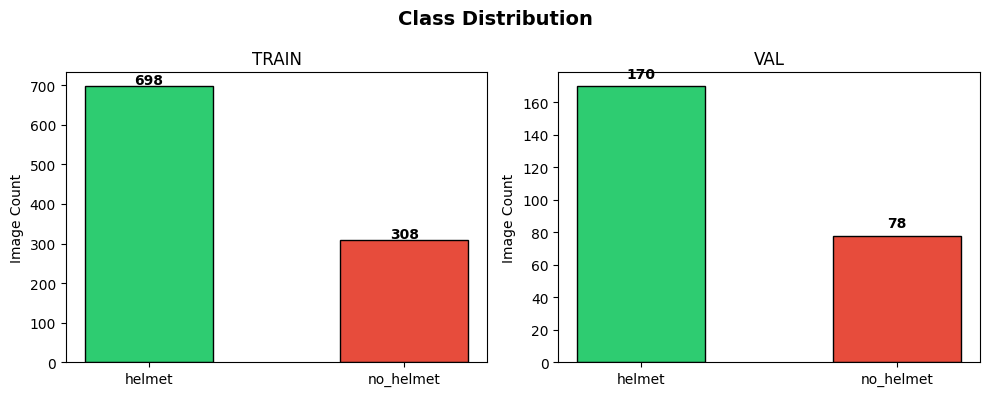

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Class Distribution', fontsize=14, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']

for i, split in enumerate(splits):
    vals = [counts[split][cls] for cls in classes]
    bars = axes[i].bar(classes, vals, color=colors, edgecolor='black', width=0.5)
    axes[i].set_title(split.upper())
    axes[i].set_ylabel('Image Count')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 5,
                     str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 — Sample Image Grid


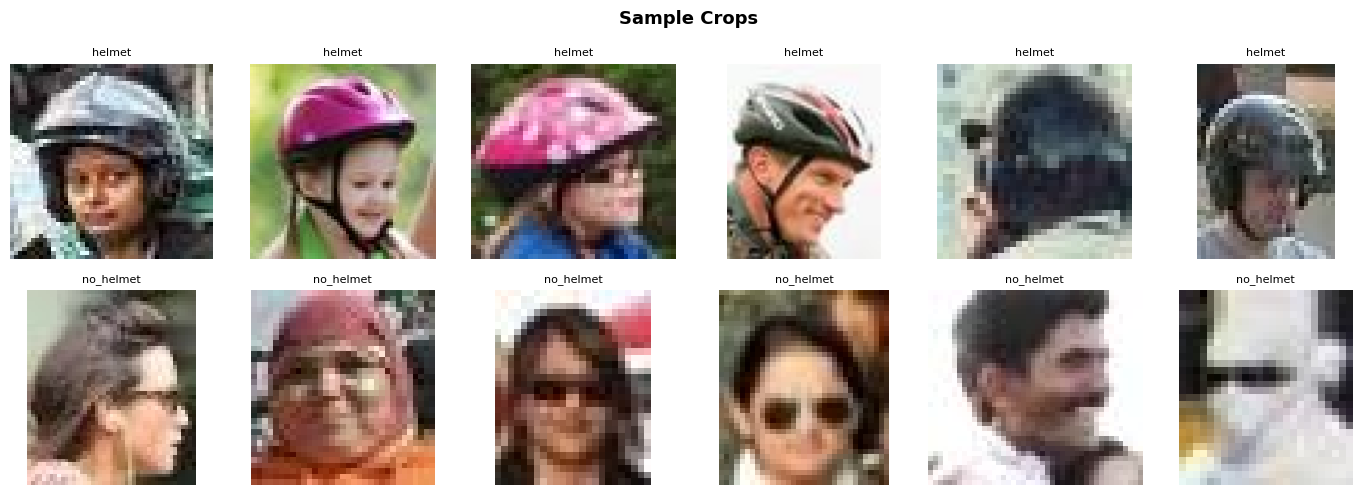

In [65]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle('Sample Crops', fontsize=13, fontweight='bold')

for row, cls in enumerate(classes):
    folder = os.path.join(OUTPUT_DIR, 'train', cls)
    samples = random.sample(os.listdir(folder), 6)
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(folder, fname))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        axes[row][col].set_title(cls, fontsize=8)

plt.tight_layout()
plt.show()

## Phase 5 — Model Training

### Step 1 — Verify GPU

In [66]:
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.6.0+cu124
GPU available   : True
GPU name        : NVIDIA GeForce RTX 2050


### Step 2 — Imports & Device Setup

In [67]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using: {device}")

✅ Using: cuda


### Step 3 — Define Transforms


In [68]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("✅ Transforms defined!")

✅ Transforms defined!


### Step 4 — Load Dataset & DataLoaders

In [69]:
train_dataset = datasets.ImageFolder('dataset/train', transform=train_transforms)
val_dataset   = datasets.ImageFolder('dataset/val',   transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(f"✅ Classes : {class_names}")
print(f"   Train   : {len(train_dataset)} images")
print(f"   Val     : {len(val_dataset)} images")

✅ Classes : ['helmet', 'no_helmet']
   Train   : 1006 images
   Val     : 248 images


### Step 5 — Handle Class Imbalance


In [77]:

helmet_count    = len(os.listdir('dataset/train/helmet'))
no_helmet_count = len(os.listdir('dataset/train/no_helmet'))
total           = helmet_count + no_helmet_count


class_weights = torch.tensor([
    total / (2 * helmet_count),
    total / (2 * no_helmet_count)
]).to(device)

print(f"✅ Class weights calculated!")
print(f"   helmet    weight : {class_weights[0]:.4f}")
print(f"   no_helmet weight : {class_weights[1]:.4f}")

✅ Class weights calculated!
   helmet    weight : 0.7206
   no_helmet weight : 1.6331


### Step 6 — Load MobileNetV2


In [78]:

model = models.mobilenet_v2(weights='IMAGENET1K_V1')


for param in model.features.parameters():
    param.requires_grad = False


model.classifier[1] = nn.Linear(model.last_channel, 2)


model = model.to(device)

print("✅ MobileNetV2 loaded!")
print(f"   Training on: {device}")

✅ MobileNetV2 loaded!
   Training on: cuda


### Step 7 — Loss Function & Optimizer

In [72]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("✅ Loss function and optimizer ready!")

✅ Loss function and optimizer ready!


### Step 8 — Training Loop


In [ ]:
EPOCHS = 10

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS):

    
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    
    model.eval()
    running_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / len(val_loader)
    val_acc  = 100 * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

print("\n✅ Training complete!")

Epoch 01/10 | Train Loss: 0.6275 | Train Acc: 63.52% | Val Loss: 0.4547 | Val Acc: 81.85%
Epoch 02/10 | Train Loss: 0.5018 | Train Acc: 74.06% | Val Loss: 0.4024 | Val Acc: 83.47%
Epoch 03/10 | Train Loss: 0.4531 | Train Acc: 78.73% | Val Loss: 0.3832 | Val Acc: 82.66%
Epoch 04/10 | Train Loss: 0.4254 | Train Acc: 80.72% | Val Loss: 0.3749 | Val Acc: 85.89%
Epoch 05/10 | Train Loss: 0.5199 | Train Acc: 75.05% | Val Loss: 0.3249 | Val Acc: 87.90%
Epoch 06/10 | Train Loss: 0.4042 | Train Acc: 81.21% | Val Loss: 0.3268 | Val Acc: 88.71%
Epoch 07/10 | Train Loss: 0.4112 | Train Acc: 80.82% | Val Loss: 0.3583 | Val Acc: 84.27%
Epoch 08/10 | Train Loss: 0.4229 | Train Acc: 81.11% | Val Loss: 0.3431 | Val Acc: 87.50%
Epoch 09/10 | Train Loss: 0.4287 | Train Acc: 78.73% | Val Loss: 0.3317 | Val Acc: 87.50%
Epoch 10/10 | Train Loss: 0.3882 | Train Acc: 82.50% | Val Loss: 0.3243 | Val Acc: 87.50%

✅ Training complete!


## Phase 6 — Evaluation

### 6.1 — Training Curves
Visualizing loss and accuracy trends across epochs to check for overfitting.

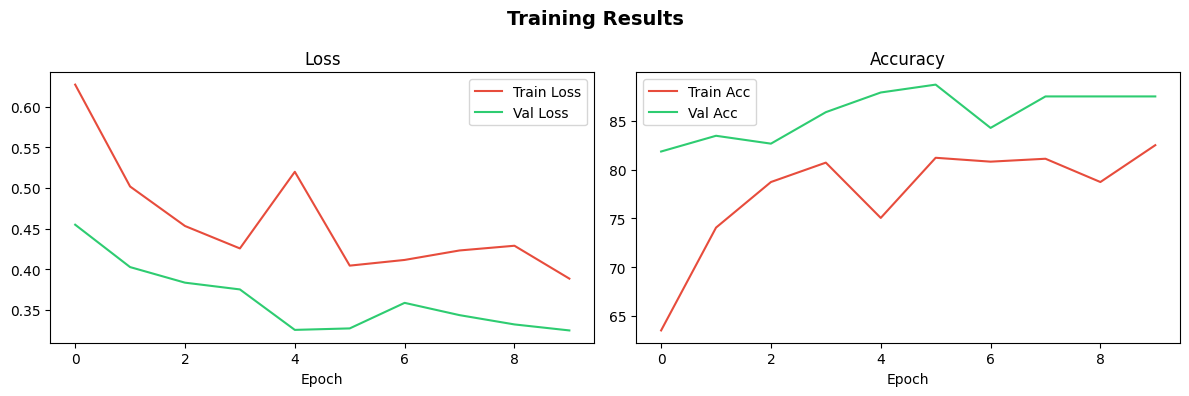

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Training Results', fontsize=14, fontweight='bold')

axes[0].plot(train_losses, label='Train Loss', color='#e74c3c')
axes[0].plot(val_losses,   label='Val Loss',   color='#2ecc71')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc', color='#e74c3c')
axes[1].plot(val_accs,   label='Val Acc',  color='#2ecc71')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 — Confusion Matrix & Classification Report

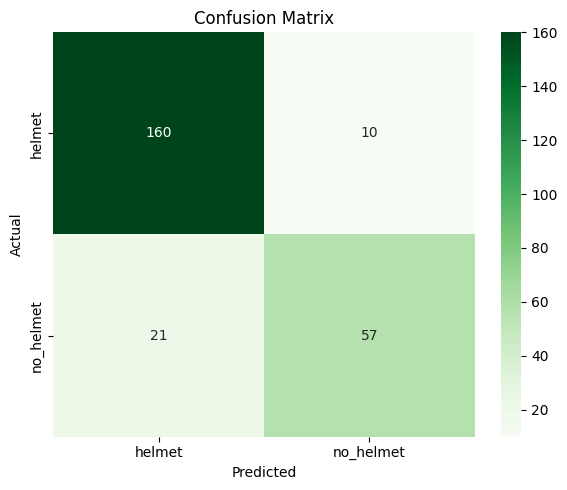

              precision    recall  f1-score   support

      helmet       0.88      0.94      0.91       170
   no_helmet       0.85      0.73      0.79        78

    accuracy                           0.88       248
   macro avg       0.87      0.84      0.85       248
weighted avg       0.87      0.88      0.87       248



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


print(classification_report(all_labels, all_preds, target_names=class_names))

## Phase 7 — Save Model


In [76]:
torch.save(model.state_dict(), 'helmet_model.pth')
print("✅ Model saved as helmet_model.pth")

✅ Model saved as helmet_model.pth
